# Ingeniería de Características: Enfermedades Cardiovasculares

## 1. Introducción

Este notebook implementa el pipeline de ingeniería de características para el dataset de enfermedades cardiovasculares, basándose en los hallazgos del Análisis Exploratorio de Datos (EDA) y utilizando los datos preprocesados.

### 1.1 Objetivos

1. Validar la calidad de los datos procesados
2. Analizar las variables derivadas creadas durante la limpieza
3. Evaluar la necesidad de transformaciones adicionales
4. Dividir los datos en conjuntos de entrenamiento y prueba
5. Aplicar normalización apropiada
6. Preparar los datos para el modelado predictivo

### 1.2 Recordatorio de Hallazgos del EDA

Del análisis exploratorio se identificó que:
- Las variables más correlacionadas con enfermedad cardiovascular son: presión arterial (sistólica y diastólica), colesterol, edad y peso
- El dataset está balanceado (50% con enfermedad, 50% sin enfermedad)
- Las variables cholesterol y gluc son ordinales (1 < 2 < 3)
- Se detectaron y eliminaron valores atípicos durante la limpieza

## 2. Importación de Bibliotecas

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats
import os
import warnings

# Configuración
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Semilla para reproducibilidad
RANDOM_STATE = 42

## 3. Carga y Validación de Datos Procesados

In [8]:
# Cargar datos limpios
df = pd.read_csv('../data/processed/cardio_clean.csv')

print(f"Dimensiones del dataset limpio: {df.shape[0]:,} registros × {df.shape[1]} variables")
print("\nVariables disponibles:")
print(df.columns.tolist())
print("\nPrimeras observaciones:")
df.head()

Dimensiones del dataset limpio: 68,240 registros × 14 variables

Variables disponibles:
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'edad_años', 'imc']

Primeras observaciones:


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,edad_años,imc
0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.4,21.97
1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.93
2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.6,23.51
3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.2,28.71
4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.8,23.01


In [9]:
# Verificar calidad de datos
print("Verificación de calidad de datos:\n")
print(f"Valores nulos: {df.isnull().sum().sum()}")
print(f"Registros duplicados: {df.duplicated().sum()}")
print("\nDistribución de la variable objetivo:")
print(df['cardio'].value_counts())
print("\nBalance de clases:")
print(df['cardio'].value_counts(normalize=True) * 100)

Verificación de calidad de datos:

Valores nulos: 0
Registros duplicados: 0

Distribución de la variable objetivo:
cardio
0    34478
1    33762
Name: count, dtype: int64

Balance de clases:
cardio
0    50.524619
1    49.475381
Name: proportion, dtype: float64


**Observación:** El dataset mantiene un balance natural entre clases (~50-50), por lo que no se requieren técnicas de balanceo artificial como SMOTE, lo cual favorece la generalización del modelo.

## 4. Análisis de Variables Derivadas

Durante el proceso de limpieza se crearon dos variables derivadas: **edad_años** e **imc** (Índice de Masa Corporal). Evaluaremos su distribución y relación con la variable objetivo.

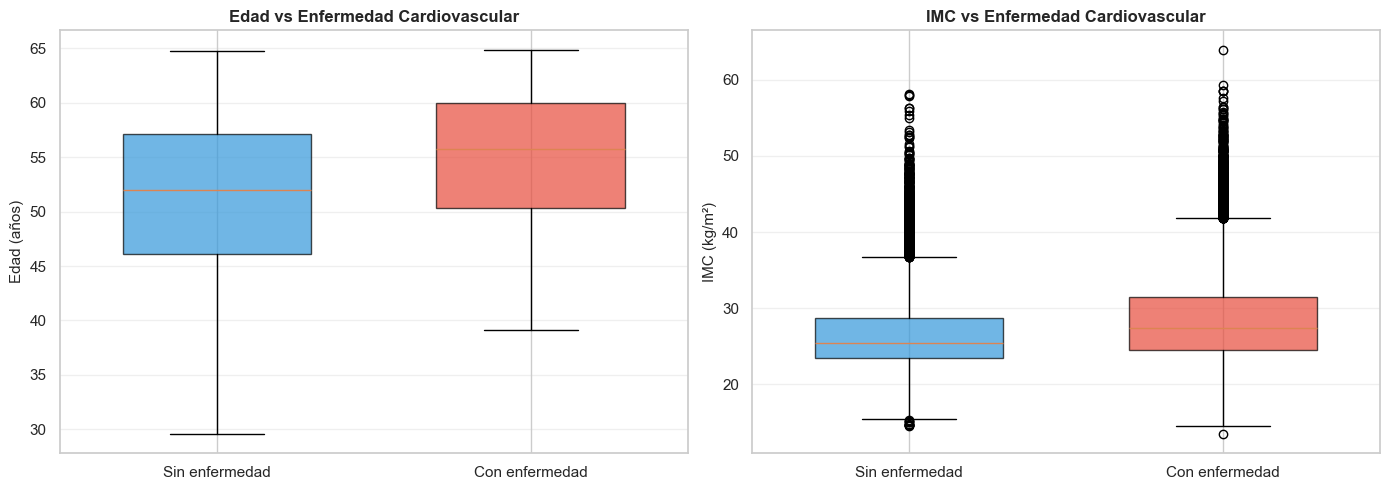

In [10]:
# Análisis de variables derivadas vs variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Edad en años
ax1 = axes[0]
datos_edad = [df[df['cardio'] == 0]['edad_años'], df[df['cardio'] == 1]['edad_años']]
bp1 = ax1.boxplot(datos_edad, labels=['Sin enfermedad', 'Con enfermedad'],
                   patch_artist=True, widths=0.6)
for patch, color in zip(bp1['boxes'], ['#3498db', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel('Edad (años)', fontsize=11)
ax1.set_title('Edad vs Enfermedad Cardiovascular', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# IMC
ax2 = axes[1]
datos_imc = [df[df['cardio'] == 0]['imc'], df[df['cardio'] == 1]['imc']]
bp2 = ax2.boxplot(datos_imc, labels=['Sin enfermedad', 'Con enfermedad'],
                   patch_artist=True, widths=0.6)
for patch, color in zip(bp2['boxes'], ['#3498db', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('IMC (kg/m²)', fontsize=11)
ax2.set_title('IMC vs Enfermedad Cardiovascular', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Comparación estadística de medias
print("Comparación de Medias entre Grupos:\n")
print(f"{'Variable':<20} {'Sin Enfermedad':<20} {'Con Enfermedad':<20} {'Diferencia':<15}")
print("="*75)

for var in ['edad_años', 'imc']:
    media_0 = df[df['cardio'] == 0][var].mean()
    media_1 = df[df['cardio'] == 1][var].mean()
    diff = media_1 - media_0
    print(f"{var:<20} {media_0:<20.2f} {media_1:<20.2f} {diff:+.2f}")

# Test t de Student para significancia
print("\n" + "="*75)
print("Test t de Student para diferencias de medias:\n")
for var in ['edad_años', 'imc']:
    t_stat, p_value = stats.ttest_ind(
        df[df['cardio'] == 0][var],
        df[df['cardio'] == 1][var]
    )
    print(f"{var}: t-statistic = {t_stat:.4f}, p-value = {p_value:.4e}")
    if p_value < 0.001:
        print("  → Diferencia altamente significativa (p < 0.001)\n")
    elif p_value < 0.05:
        print("  → Diferencia significativa (p < 0.05)\n")

Comparación de Medias entre Grupos:

Variable             Sin Enfermedad       Con Enfermedad       Diferencia     
edad_años            51.69                54.93                +3.23
imc                  26.45                28.42                +1.98

Test t de Student para diferencias de medias:

edad_años: t-statistic = -64.3977, p-value = 0.0000e+00
  → Diferencia altamente significativa (p < 0.001)

imc: t-statistic = -51.3685, p-value = 0.0000e+00
  → Diferencia altamente significativa (p < 0.001)



**Interpretación:** Ambas variables derivadas (edad e IMC) muestran diferencias estadísticamente significativas entre grupos, confirmando su relevancia para la predicción de enfermedades cardiovasculares.

## 5. Evaluación de Multicolinealidad

Dado que se han creado variables derivadas, es importante evaluar la multicolinealidad, especialmente entre:
- `age` y `edad_años` (redundantes)
- `weight`, `height` e `imc` (el IMC se deriva de peso y altura)
- `ap_hi` y `ap_lo` (presiones sistólica y diastólica, correlacionadas pero no redundantes)

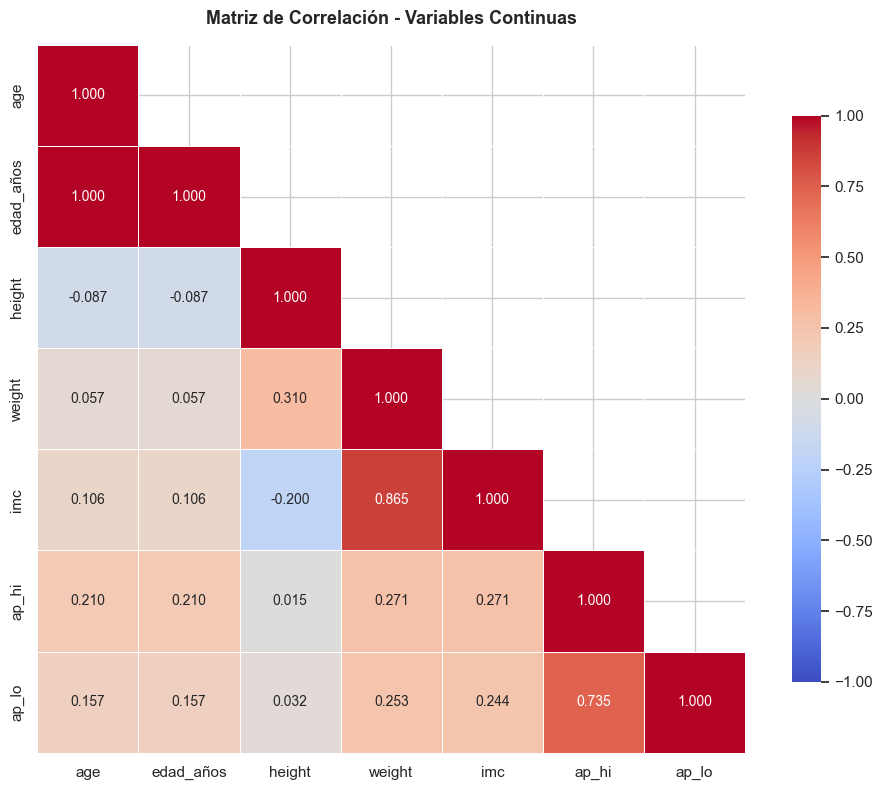

In [12]:
# Matriz de correlación entre variables continuas
vars_continuas = ['age', 'edad_años', 'height', 'weight', 'imc', 'ap_hi', 'ap_lo']
corr_matrix = df[vars_continuas].corr()

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Matriz de Correlación - Variables Continuas', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [13]:
# Identificar variables redundantes
print("Análisis de Multicolinealidad:\n")
print(f"Correlación age vs edad_años: {corr_matrix.loc['age', 'edad_años']:.4f}")
print("  → Perfectamente colineales (misma información)\n")

print(f"Correlación weight vs imc: {corr_matrix.loc['weight', 'imc']:.4f}")
print(f"Correlación height vs imc: {corr_matrix.loc['height', 'imc']:.4f}")
print("  → IMC captura información de peso y altura de forma normalizada\n")

print(f"Correlación ap_hi vs ap_lo: {corr_matrix.loc['ap_hi', 'ap_lo']:.4f}")
print("  → Alta correlación pero aportan información complementaria\n")

Análisis de Multicolinealidad:

Correlación age vs edad_años: 1.0000
  → Perfectamente colineales (misma información)

Correlación weight vs imc: 0.8651
Correlación height vs imc: -0.1996
  → IMC captura información de peso y altura de forma normalizada

Correlación ap_hi vs ap_lo: 0.7351
  → Alta correlación pero aportan información complementaria



**Decisión:** Se eliminarán las variables redundantes para evitar multicolinealidad:
- **Eliminar `age`:** Mantener `edad_años` (más interpretable)
- **Eliminar `weight` y `height`:** Mantener `imc` (normaliza ambas medidas e identifica obesidad)
- **Mantener `ap_hi` y `ap_lo`:** Aunque correlacionadas, aportan información clínica diferenciada

## 6. Selección de Variables Finales

Basándose en los hallazgos del EDA, el análisis de multicolinealidad y la literatura médica, se seleccionan las siguientes variables para el modelado:

In [14]:
# Variables seleccionadas
variables_modelo = [
    # Variables derivadas (más interpretables)
    'edad_años',
    'imc',
    
    # Variables clínicas (alta correlación con objetivo)
    'ap_hi',        # Presión sistólica
    'ap_lo',        # Presión diastólica
    'cholesterol',  # Nivel de colesterol (ordinal: 1, 2, 3)
    'gluc',         # Nivel de glucosa (ordinal: 1, 2, 3)
    
    # Variables demográficas y de estilo de vida
    'gender',       # Sexo (1: mujer, 2: hombre)
    'smoke',        # Tabaquismo (0: no, 1: sí)
    'alco',         # Consumo de alcohol (0: no, 1: sí)
    'active'        # Actividad física (0: no, 1: sí)
]

# Crear dataset con variables seleccionadas
X = df[variables_modelo].copy()
y = df['cardio'].copy()

print(f"Variables seleccionadas para modelado: {len(variables_modelo)}")
print("\nListado de variables:")
for i, var in enumerate(variables_modelo, 1):
    print(f"  {i:2d}. {var}")

print(f"\nDimensiones finales: X = {X.shape}, y = {y.shape}")

Variables seleccionadas para modelado: 10

Listado de variables:
   1. edad_años
   2. imc
   3. ap_hi
   4. ap_lo
   5. cholesterol
   6. gluc
   7. gender
   8. smoke
   9. alco
  10. active

Dimensiones finales: X = (68240, 10), y = (68240,)


**Justificación:** Las variables cholesterol y gluc se mantienen como ordinales (1, 2, 3) sin aplicar one-hot encoding, ya que:
1. Representan un orden natural creciente de severidad
2. Los algoritmos de árbol (Random Forest, XGBoost) manejan bien variables ordinales
3. Reduce la dimensionalidad del modelo

## 7. Partición de Datos

Se divide el dataset en conjuntos de entrenamiento (80%) y prueba (20%), utilizando estratificación para mantener la proporción de clases.

In [15]:
# División estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Conjunto de Entrenamiento: {X_train.shape[0]:,} registros ({(X_train.shape[0]/len(X))*100:.1f}%)")
print(f"Conjunto de Prueba: {X_test.shape[0]:,} registros ({(X_test.shape[0]/len(X))*100:.1f}%)")

# Verificar balance en ambos conjuntos
print("\nDistribución de clases en Entrenamiento:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribución de clases en Prueba:")
print(y_test.value_counts(normalize=True).sort_index())

Conjunto de Entrenamiento: 54,592 registros (80.0%)
Conjunto de Prueba: 13,648 registros (20.0%)

Distribución de clases en Entrenamiento:
cardio
0    0.505239
1    0.494761
Name: proportion, dtype: float64

Distribución de clases en Prueba:
cardio
0    0.505275
1    0.494725
Name: proportion, dtype: float64


**Observación:** La estratificación mantiene el balance natural 50-50 en ambos conjuntos, por lo que no se requiere sobremuestreo (SMOTE) ni submuestreo.

## 8. Normalización de Variables

Se aplica normalización StandardScaler únicamente al conjunto de entrenamiento, y se aplica la misma transformación al conjunto de prueba para evitar fuga de información (data leakage).

In [20]:
# Inicializar escalador
scaler = StandardScaler()

# Ajustar y transformar conjunto de entrenamiento
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# Transformar conjunto de prueba (sin ajustar)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Normalización aplicada correctamente")
print("\nEstadísticas del conjunto de entrenamiento normalizado:")
# print(X_train_scaled.describe().round(3))
display(X_train_scaled.describe().round(3))

Normalización aplicada correctamente

Estadísticas del conjunto de entrenamiento normalizado:


,edad_años,imc,ap_hi,ap_lo,cholesterol,gluc,gender,smoke,alco,active
count,54592.000,54592.000,54592.000,54592.000,54592.000,54592.000,54592.000,54592.000,54592.000,54592.000
mean,0.000,-0.000,-0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-3.509,-2.718,-2.835,-2.299,-0.537,-0.395,-0.729,-0.311,-0.237,-2.025
25%,-0.726,-0.692,-0.402,-0.143,-0.537,-0.395,-0.729,-0.311,-0.237,0.494
50%,0.088,-0.208,-0.402,-0.143,-0.537,-0.395,-0.729,-0.311,-0.237,0.494
75%,0.754,0.529,0.815,0.935,0.934,-0.395,1.371,-0.311,-0.237,0.494
max,1.716,7.154,4.465,6.324,2.405,3.108,1.371,3.213,4.226,0.494


In [17]:
# Verificar normalización
print("Verificación de normalización (debe ser ~0 media, ~1 desviación estándar):\n")
print(f"Media del conjunto de entrenamiento: {X_train_scaled.mean().mean():.6f}")
print(f"Desviación estándar del conjunto de entrenamiento: {X_train_scaled.std().mean():.6f}")

Verificación de normalización (debe ser ~0 media, ~1 desviación estándar):

Media del conjunto de entrenamiento: -0.000000
Desviación estándar del conjunto de entrenamiento: 1.000009


## 9. Exportación de Datos Procesados

Se guardan los conjuntos de entrenamiento y prueba en formato CSV para su uso en la fase de modelado.

In [18]:
# Crear directorio de salida
output_dir = '../data/processed/model_inputs/'
os.makedirs(output_dir, exist_ok=True)

# Guardar datasets
X_train_scaled.to_csv(output_dir + 'X_train.csv', index=False)
X_test_scaled.to_csv(output_dir + 'X_test.csv', index=False)
y_train.to_csv(output_dir + 'y_train.csv', index=False, header=True)
y_test.to_csv(output_dir + 'y_test.csv', index=False, header=True)

print(f"Datasets guardados en: {output_dir}")
print("\nArchivos generados:")
print(f"  - X_train.csv: {X_train_scaled.shape}")
print(f"  - X_test.csv: {X_test_scaled.shape}")
print(f"  - y_train.csv: {y_train.shape}")
print(f"  - y_test.csv: {y_test.shape}")

Datasets guardados en: ../data/processed/model_inputs/

Archivos generados:
  - X_train.csv: (54592, 10)
  - X_test.csv: (13648, 10)
  - y_train.csv: (54592,)
  - y_test.csv: (13648,)


## 10. Resumen del Proceso de Feature Engineering

### 10.1 Transformaciones Aplicadas

1. **Eliminación de variables redundantes:**
   - `age` → Reemplazada por `edad_años` (más interpretable)
   - `weight` y `height` → Reemplazadas por `imc` (normalización e indicador de obesidad)

2. **Variables derivadas mantenidas:**
   - `edad_años`: Conversión de días a años
   - `imc`: Índice de Masa Corporal (kg/m²)

3. **Variables ordinales sin transformación:**
   - `cholesterol` y `gluc`: Mantenidas como ordinales (1, 2, 3)
   - Justificación: Representan orden natural y reducen dimensionalidad

4. **División de datos:**
   - 80% entrenamiento, 20% prueba
   - Estratificación para mantener balance de clases

5. **Normalización:**
   - StandardScaler aplicado correctamente (fit en train, transform en test)
   - Previene data leakage

### 10.2 Decisiones Clave

**No se aplicó SMOTE ni otras técnicas de balanceo porque:**
- El dataset está naturalmente balanceado (50-50)
- El sobremuestreo artificial puede llevar a overfitting
- Se prioriza la generalización del modelo

**Se mantuvieron variables ordinales sin one-hot encoding porque:**
- Conservan el orden natural de severidad
- Reducen la dimensionalidad
- Los algoritmos de árbol las procesan eficientemente

### 10.3 Próximos Pasos

1. Entrenamiento de modelos base (Regresión Logística, Random Forest, XGBoost)
2. Validación cruzada y optimización de hiperparámetros
3. Evaluación con métricas apropiadas (Accuracy, Precision, Recall, F1-Score, ROC-AUC)
4. Análisis de importancia de características
5. Interpretabilidad del modelo final